# Importing data

In [1]:
import pandas as pd
import numpy as np

pd.set_option("mode.copy_on_write", True)

# Load the data
class_df = pd.read_csv("../cleaned_data/EMA/Class.csv")
behavior = pd.read_csv("../cleaned_data/EMA/Behaviour_new.csv")
depression = pd.read_csv("../cleaned_data/surveys/clean_PHQ-9.csv")
grades = pd.read_csv("../cleaned_data/education/grades.csv")
exercise = pd.read_csv("../cleaned_data/EMA/Exercise.csv")
mood = pd.read_csv("../cleaned_data/EMA/Mood.csv")
sleep = pd.read_csv("../cleaned_data/EMA/Sleep.csv")
social = pd.read_csv("../cleaned_data/EMA/Social.csv")
stress = pd.read_csv("../cleaned_data/EMA/Stress.csv")

# Drop unnecessary columns
class_df.drop(columns=["resp_time", "location", "course_id"], inplace=True)
behavior.drop(columns=["resp_time", "datetime_utc"], inplace=True)

# Other cleaning
depression = depression.loc[depression["type"] == "post"]
depression_score = depression[["uid", "total_score"]]
depression_score.rename(
    columns={
        "uid": "user_id",
    },
    inplace=True,
)
grades.rename(
    columns={
        "gpa 13s": "gpa_13s",
        "gpa all": "gpa_all",
        "cs 65": "cs_65",
        "uid": "user_id",
    },
    inplace=True,
)


# Group by user_id and calculate the mean for each user
class_grp = class_df.groupby(["user_id"]).mean()
exercise = exercise[["user_id", "exercise", "walk"]].groupby("user_id").mean()
mood = mood[["user_id", "happy", "happyornot"]].groupby("user_id").mean()
sleep = (
    sleep[["user_id", "sleep_hours", "sleep_quality", "sleepiness"]]
    .groupby("user_id")
    .mean()
)
social = social[["user_id", "number"]].groupby("user_id").mean()
stress = stress[["user_id", "level"]].groupby("user_id").mean()
behavior_grp = behavior.groupby(["user_id"]).mean()

# Merge all dataframes on user_id
merged_behavior = behavior_grp.merge(
    depression_score, on="user_id", how="inner", validate="1:1"
)
merged_grades = merged_behavior.merge(grades, on="user_id", how="inner", validate="1:1")
merged_class = merged_grades.merge(class_grp, on="user_id", how="inner", validate="1:1")
merged_exercise = merged_class.merge(
    exercise, on="user_id", how="inner", validate="1:1"
)
merged_mood = merged_exercise.merge(mood, on="user_id", how="inner", validate="1:1")
merged_sleep = merged_mood.merge(sleep, on="user_id", how="inner", validate="1:1")
merged_stress = merged_sleep.merge(stress, on="user_id", how="inner", validate="1:1")
merged_final = merged_stress.merge(social, on="user_id", how="inner", validate="1:1")
merged_final

,user_id,anxious,calm,conventional,critical,dependable,disorganized,enthusiastic,experiences,reserved,...,hours,exercise,walk,happy,happyornot,sleep_hours,sleep_quality,sleepiness,level,number
0,u01,1.000000,5.000000,5.000000,1.000000,3.000000,2.000000,3.000000,3.000000,5.000000,...,2.133333,1.000000,2.428571,2.000000,1.000000,7.222222,1.592593,1.851852,2.250000,3.500000
1,u02,1.500000,4.500000,2.500000,2.500000,2.500000,2.000000,5.000000,3.000000,2.000000,...,4.333333,2.000000,2.416667,1.000000,2.000000,7.923077,2.000000,1.384615,2.066667,2.800000
2,u04,3.500000,2.500000,3.250000,3.500000,3.000000,2.750000,3.000000,3.000000,3.500000,...,3.272727,4.083333,2.583333,1.750000,1.000000,6.470588,2.058824,1.000000,1.860465,3.074074
3,u07,2.076923,3.846154,3.000000,1.846154,3.076923,1.000000,3.384615,2.923077,4.000000,...,3.480000,2.384615,2.307692,1.000000,1.000000,7.041667,2.000000,1.041667,3.245283,3.250000
4,u10,2.000000,3.000000,2.000000,3.600000,3.400000,2.200000,3.200000,2.400000,3.400000,...,3.777778,1.700000,2.100000,1.333333,1.555556,7.787234,2.106383,1.191489,2.396226,3.133333
5,u14,1.000000,4.333333,3.000000,1.000000,3.333333,1.666667,3.000000,2.666667,3.333333,...,3.608696,1.000000,3.750000,2.000000,1.000000,6.966667,1.666667,1.366667,2.162162,3.230769
6,u16,2.333333,3.166667,3.388889,2.611111,2.888889,2.555556,2.500000,2.611111,4.000000,...,5.000000,1.868421,2.578947,2.047619,1.095238,7.907692,1.938462,1.215385,2.130841,3.025000
7,u17,3.272727,3.727273,1.363636,2.363636,3.272727,2.818182,4.000000,4.545455,4.454545,...,7.125000,1.190476,2.666667,1.100000,1.700000,4.900000,2.675000,2.400000,2.857143,2.451613
8,u18,3.000000,3.000000,3.090909,2.833333,3.000000,3.000000,3.166667,3.083333,3.166667,...,2.280000,2.600000,2.400000,1.000000,1.000000,5.909091,1.757576,1.757576,1.875000,1.954545
9,u19,2.377778,3.866667,3.488889,1.688889,4.355556,1.577778,2.933333,3.444444,3.844444,...,4.750000,2.772727,2.340909,1.791667,1.041667,7.836364,1.654545,2.272727,1.978022,3.487179


# Feature Selection

In [2]:
from sklearn.feature_selection import VarianceThreshold

selector = VarianceThreshold(threshold=0.1)
selector.fit_transform(merged_final.loc[:, merged_final.columns != "user_id"])

array([[ 1.        ,  5.        ,  5.        ,  1.        ,  3.        ,
         2.        ,  3.        ,  3.        ,  5.        ,  3.        ,
         4.        ,  2.863     ,  1.77777778,  3.        ,  3.5       ,
         2.13333333,  1.        ,  2.42857143,  2.        ,  7.22222222,
         1.59259259,  1.85185185,  2.25      ,  3.5       ],
       [ 1.5       ,  4.5       ,  2.5       ,  2.5       ,  2.5       ,
         2.        ,  5.        ,  3.        ,  2.        ,  4.5       ,
         5.        ,  3.505     ,  4.        ,  4.        ,  2.11111111,
         4.33333333,  2.        ,  2.41666667,  1.        ,  7.92307692,
         2.        ,  1.38461538,  2.06666667,  2.8       ],
       [ 3.5       ,  2.5       ,  3.25      ,  3.5       ,  3.        ,
         2.75      ,  3.        ,  3.        ,  3.5       ,  3.        ,
         8.        ,  3.029     ,  3.5       ,  4.        ,  1.63636364,
         3.27272727,  4.08333333,  2.58333333,  1.75      ,  6.47058824,
  

In [3]:
# Split the data into features and target variable
y = merged_final["total_score"]
X = merged_final.drop(
    columns=[
        "total_score",
    ]
)

# Convert user_id to int64
X["user_id"] = X["user_id"].replace("[^0-9]", "", regex=True).astype("int64")
X

,user_id,anxious,calm,conventional,critical,dependable,disorganized,enthusiastic,experiences,reserved,...,hours,exercise,walk,happy,happyornot,sleep_hours,sleep_quality,sleepiness,level,number
0,1,1.000000,5.000000,5.000000,1.000000,3.000000,2.000000,3.000000,3.000000,5.000000,...,2.133333,1.000000,2.428571,2.000000,1.000000,7.222222,1.592593,1.851852,2.250000,3.500000
1,2,1.500000,4.500000,2.500000,2.500000,2.500000,2.000000,5.000000,3.000000,2.000000,...,4.333333,2.000000,2.416667,1.000000,2.000000,7.923077,2.000000,1.384615,2.066667,2.800000
2,4,3.500000,2.500000,3.250000,3.500000,3.000000,2.750000,3.000000,3.000000,3.500000,...,3.272727,4.083333,2.583333,1.750000,1.000000,6.470588,2.058824,1.000000,1.860465,3.074074
3,7,2.076923,3.846154,3.000000,1.846154,3.076923,1.000000,3.384615,2.923077,4.000000,...,3.480000,2.384615,2.307692,1.000000,1.000000,7.041667,2.000000,1.041667,3.245283,3.250000
4,10,2.000000,3.000000,2.000000,3.600000,3.400000,2.200000,3.200000,2.400000,3.400000,...,3.777778,1.700000,2.100000,1.333333,1.555556,7.787234,2.106383,1.191489,2.396226,3.133333
5,14,1.000000,4.333333,3.000000,1.000000,3.333333,1.666667,3.000000,2.666667,3.333333,...,3.608696,1.000000,3.750000,2.000000,1.000000,6.966667,1.666667,1.366667,2.162162,3.230769
6,16,2.333333,3.166667,3.388889,2.611111,2.888889,2.555556,2.500000,2.611111,4.000000,...,5.000000,1.868421,2.578947,2.047619,1.095238,7.907692,1.938462,1.215385,2.130841,3.025000
7,17,3.272727,3.727273,1.363636,2.363636,3.272727,2.818182,4.000000,4.545455,4.454545,...,7.125000,1.190476,2.666667,1.100000,1.700000,4.900000,2.675000,2.400000,2.857143,2.451613
8,18,3.000000,3.000000,3.090909,2.833333,3.000000,3.000000,3.166667,3.083333,3.166667,...,2.280000,2.600000,2.400000,1.000000,1.000000,5.909091,1.757576,1.757576,1.875000,1.954545
9,19,2.377778,3.866667,3.488889,1.688889,4.355556,1.577778,2.933333,3.444444,3.844444,...,4.750000,2.772727,2.340909,1.791667,1.041667,7.836364,1.654545,2.272727,1.978022,3.487179


## Forward Selection

In [4]:
import statsmodels.api as sm

# Create an empty dictionary that will be used to store our results
function_dict = {"predictor": [], "r-squared": []}
# Iterate through every column in X
for col in X.columns:
    # Create a dataframe called selected_X with only the 1 column
    selected_X = X[[col]]
    # Fit a model for our target and our selected column
    model = sm.OLS(y, sm.add_constant(selected_X)).fit()
    # Predict what our target would be for our model
    y_preds = model.predict(sm.add_constant(selected_X))
    # Add the column name to our dictionary
    function_dict["predictor"].append(col)
    # Calculate the r-squared value between the target and predicted target
    r2 = np.corrcoef(y, y_preds)[0, 1] ** 2
    # Add the r-squared value to our dictionary
    function_dict["r-squared"].append(r2)

# Once it's iterated through every column, turn our dictionary into a DataFrame and sort it
function_df = pd.DataFrame(function_dict).sort_values(by=["r-squared"], ascending=False)
# Display only the top 5 predictors
function_df

,predictor,r-squared
11,gpa_all,0.304158
1,anxious,0.263567
12,gpa_13s,0.169195
21,sleep_hours,0.152217
9,reserved,0.139790
20,happyornot,0.137284
6,disorganized,0.134136
19,happy,0.128858
16,hours,0.099377
10,sympathetic,0.074407


In [5]:
def next_possible_feature(X_npf, y_npf, current_features, ignore_features=[]):
    """
    This function will loop through each column that isn't in your feature model and
    calculate the r-squared value if it were the next feature added to your model.
    It will display a dataframe with a sorted r-squared value.
    X_npf = X dataframe
    y_npf = y dataframe
    current_features = list of features that are already in your model
    ignore_features = list of unused features we want to skip over
    """
    # Create an empty dictionary that will be used to store our results
    function_dict = {"predictor": [], "r-squared": []}
    # Iterate through every column in X
    for col in X_npf.columns:
        # But only create a model if the feature isn't already selected or ignored
        if col not in (current_features + ignore_features):
            # Create a dataframe called function_X with our current features + 1
            selected_X = X_npf[current_features + [col]]
            # Fit a model for our target and our selected columns
            model = sm.OLS(y_npf, sm.add_constant(selected_X)).fit()
            # Predict what  our target would be for our selected columns
            y_preds = model.predict(sm.add_constant(selected_X))
            # Add the column name to our dictionary
            function_dict["predictor"].append(col)
            # Calculate the r-squared value between the target and predicted target
            r2 = np.corrcoef(y_npf, y_preds)[0, 1] ** 2
            # Add the r-squared value to our dictionary
            function_dict["r-squared"].append(r2)
    # Once it's iterated through every column, turn our dict into a sorted DataFrame
    function_df = pd.DataFrame(function_dict).sort_values(
        by=["r-squared"], ascending=False
    )
    return function_df


next_possible_feature(X, y, ["gpa_all"], ignore_features=["user_id"])

,predictor,r-squared
14,hours,0.523644
7,experiences,0.468126
2,conventional,0.463263
20,sleep_quality,0.459848
19,sleep_hours,0.452134
0,anxious,0.427455
17,happy,0.399266
18,happyornot,0.391369
21,sleepiness,0.379888
22,level,0.373553


## VIF Calculations

In [6]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

# Define an empty dataframe to capture the VIF scores
vif_2 = pd.DataFrame()
# Create a Dataframe with only our selected features
X_2 = X[["gpa_all", "disorganized"]]
# Label the scores with their related columns
vif_2["features"] = X_2.columns
# For each column,run a variance_inflaction_factor against all other columns
# to get a VIF Factor score
vif_2["VIF"] = [
    variance_inflation_factor(X_2.values, i) for i in range(len(X_2.columns))
]
vif_2

,features,VIF
0,gpa_all,6.324483
1,disorganized,6.324483


In [7]:
# Define an empty dataframe to capture the VIF scores
vif_3 = pd.DataFrame()
# Create a Dataframe with only our selected features
# X_3 = X[["gpa_all", "disorganized", "hours", "level"]]
# X_3 = X[
#     [
# "anxious",
# "calm",
# "conventional",
# "critical",
# "dependable",
# "disorganized",
# "enthusiastic",
# "experiences",
# "reserved",
# "sympathetic",
#  'user_id',
#  'total_score',
#         "gpa_all",
#         "gpa_13s",
#         "cs_65",
#         "due",
#         "experience",
#         "hours",
#         "exercise",
#         "walk",
#         "happy",
#         "happyornot",
#         "sleep_hours",
#         "sleep_quality",
#         "sleepiness",
#         "level",
#         "number",
#     ]
# ]
X_3 = X[["anxious", "gpa_all", "cs_65", "due", "sleep_quality"]]
# Label the scores with their related columns
vif_3["features"] = X_3.columns
# For each column,run a variance_inflaction_factor against all other columns
# to get a VIF Factor score
vif_3["VIF"] = [
    variance_inflation_factor(X_3.values, i) for i in range(len(X_3.columns))
]
vif_3

,features,VIF
0,anxious,16.937329
1,gpa_all,79.169550
2,cs_65,40.771196
3,due,60.637951
4,sleep_quality,51.093429


## Recursive Feature Elimination

In [8]:
from sklearn.feature_selection import RFE
from sklearn.linear_model import LinearRegression

# Apply RFE with logistic regression
lin_model = LinearRegression()
rfe = RFE(lin_model, n_features_to_select=5)
X_train_rfe = rfe.fit_transform(X, y)

print("Selected features:", X.columns[rfe.get_support()])

Selected features: Index(['anxious', 'gpa_all', 'cs_65', 'exercise', 'sleepiness'], dtype='object')


## Correlation Matrix

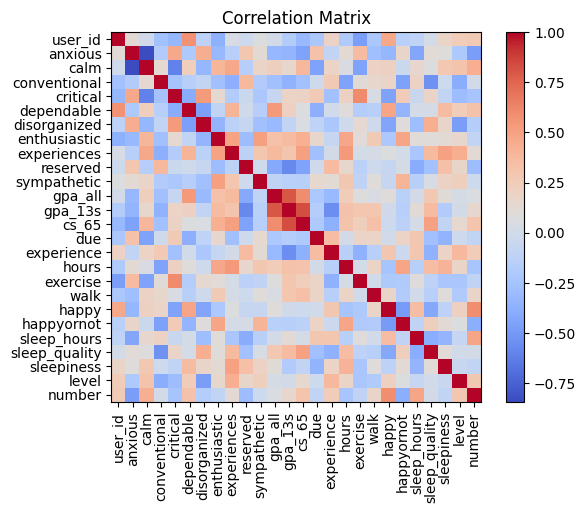

In [9]:
import matplotlib.pyplot as plt


plt.imshow(X.corr(), cmap="coolwarm", interpolation="nearest")
variables = []
for i in X.corr().columns:
    variables.append(i)

plt.xticks(range(len(variables)), variables, rotation=90)
plt.yticks(range(len(variables)), variables)
plt.title("Correlation Matrix")

plt.colorbar()
plt.show()

## Box Plot

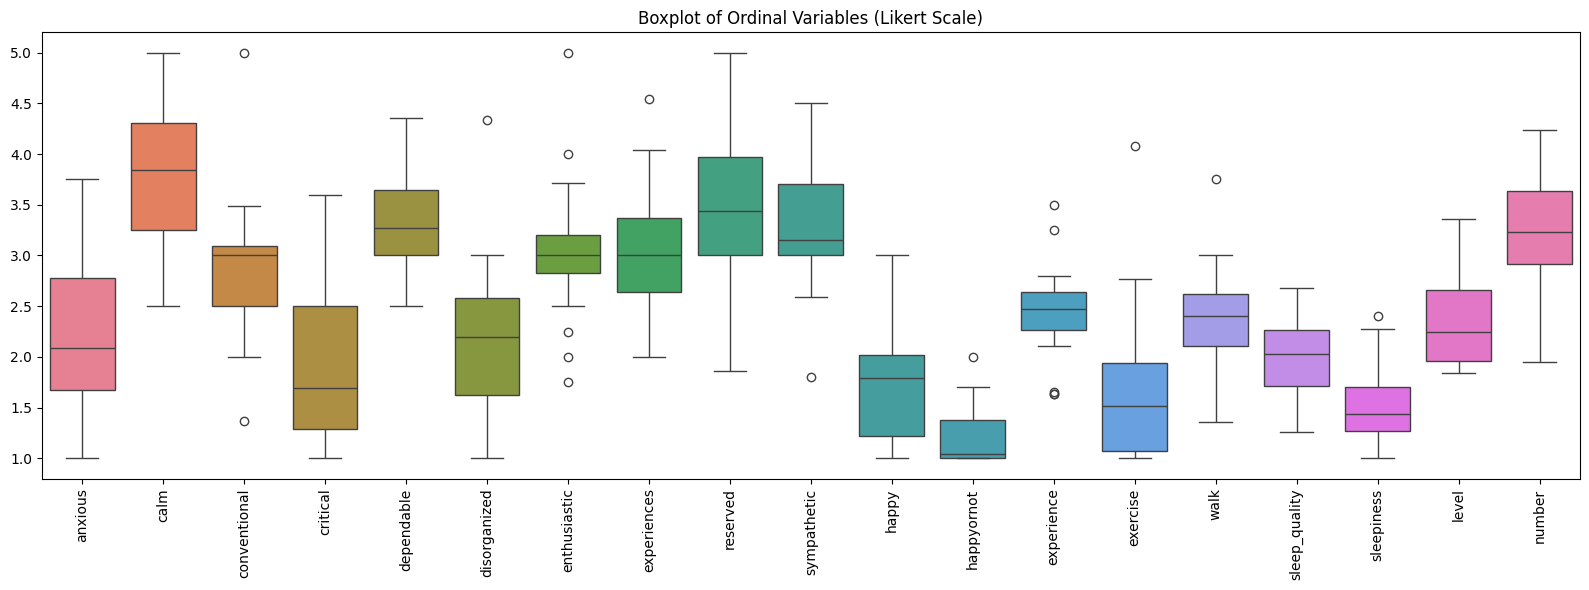

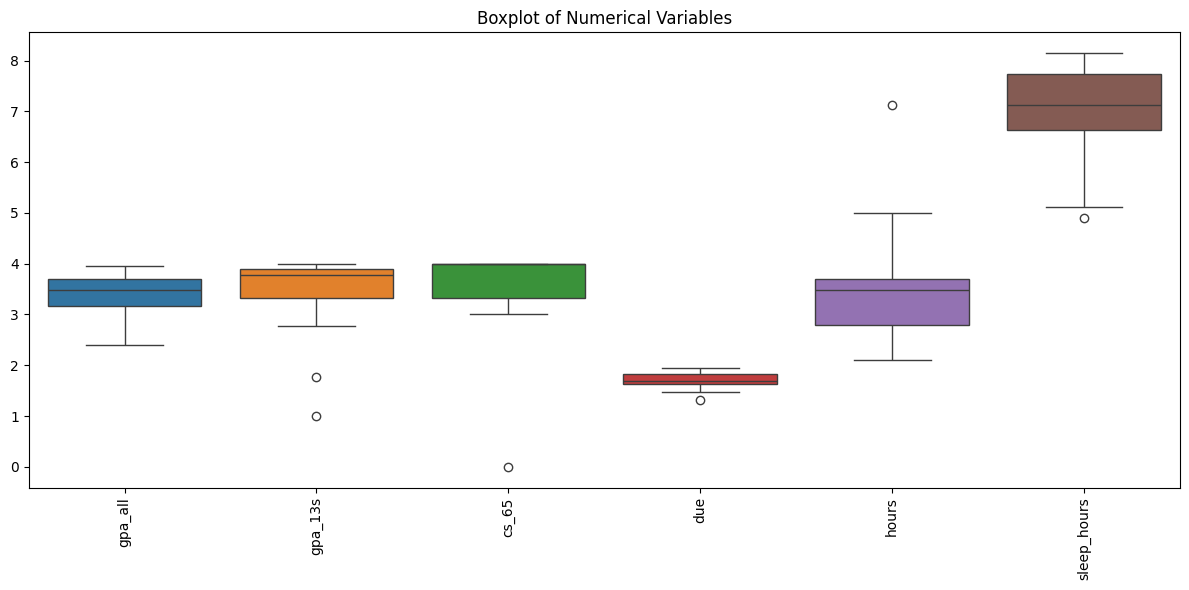

In [26]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

ordinal_cols = [
    'anxious', 'calm', 'conventional', 'critical', 'dependable', 'disorganized', 
    'enthusiastic', 'experiences', 'reserved', 'sympathetic', 'happy', 'happyornot','experience','exercise','walk',
    'sleep_quality', 'sleepiness', 'level', 'number'
]
numeric_cols = [
    'gpa_all', 'gpa_13s', 'cs_65', 'due',  'hours',  'sleep_hours'
]

# Boxplot for Ordinal variables
plt.figure(figsize=(16, 6))
sns.boxplot(data=X[ordinal_cols])
plt.title("Boxplot of Ordinal Variables (Likert Scale)")
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

# Boxplot for Numerical variables
plt.figure(figsize=(12, 6))
sns.boxplot(data=X[numeric_cols])
plt.title("Boxplot of Numerical Variables")
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

## Linear Regression

In [10]:
selected_features = [
    "gpa_all",
    "hours",
    "sleep_hours",
    "walk",
    "cs_65",
    "anxious",
    "exercise",
]
features_ignore = ["user_id"]

next_possible_feature(X, y, selected_features, features_ignore)

,predictor,r-squared
14,sleep_quality,0.780613
16,level,0.763509
0,calm,0.762627
6,experiences,0.759234
4,disorganized,0.758807
2,critical,0.757910
3,dependable,0.757068
8,sympathetic,0.756190
15,sleepiness,0.755612
10,due,0.751234


In [11]:
shortened_X = X[
    [
        "gpa_all",
        "hours",
        "sleep_hours",
        "walk",
        "cs_65",
        "anxious",
        "exercise",
    ]
]
shortened_X.columns = range(len(shortened_X.columns))
shortened_X

,0,1,2,3,4,5,6
0,2.863,2.133333,7.222222,2.428571,3.000000,1.000000,1.000000
1,3.505,4.333333,7.923077,2.416667,4.000000,1.500000,2.000000
2,3.029,3.272727,6.470588,2.583333,4.000000,3.500000,4.083333
3,3.474,3.480000,7.041667,2.307692,4.000000,2.076923,2.384615
4,3.667,3.777778,7.787234,2.100000,4.000000,2.000000,1.700000
5,3.293,3.608696,6.966667,3.750000,3.666667,1.000000,1.000000
6,3.373,5.000000,7.907692,2.578947,4.000000,2.333333,1.868421
7,3.476,7.125000,4.900000,2.666667,4.000000,3.272727,1.190476
8,3.474,2.280000,5.909091,2.400000,3.333333,3.000000,2.600000
9,3.947,4.750000,7.836364,2.340909,3.333333,2.377778,2.772727


In [12]:
from sklearn.model_selection import StratifiedKFold

n_splits = 3
folds = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=42)

In [13]:
from statsmodels.formula.api import ols
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, r2_score

y = np.array(y)
n_static = shortened_X.shape[1]
n_classes = len(np.unique(y))

fold_metrics = []

for fold, (train_idx, test_idx) in enumerate(folds.split(shortened_X, y)):
    print(f"\n🔁 Fold {fold + 1}/{n_splits}")

    # Split

    X_train, X_test = (
        shortened_X.iloc[train_idx],
        shortened_X.iloc[test_idx],
    )
    y_train, y_test = y[train_idx], y[test_idx]

    # Build and train
    # regressor = ols(
    #     "total_score ~ gpa_all + hours + sleep_hours + walk + cs_65 + anxious + exercise",
    #     data=merged_final,
    # ).fit()

    regressor = LinearRegression()
    regressor.fit(X_train, y_train)

    # Predict class probabilities and take argmax
    y_pred = regressor.predict(X_test)

    # Calculate Mean Absolute Error (ordinal-aware)
    mae = mean_absolute_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)

    print(f"MAE: {mae:.3f}")
    print(f"R2: {r2:.3f}")

    # fig, ax = plt.subplots(ncols=2, figsize=(10, 5), sharex=True, sharey=True)

    # ax[0].scatter(X_train, y_train, label="Train data points")
    # ax[0].plot(
    #     X_train,
    #     regressor.predict(X_train),
    #     linewidth=3,
    #     color="tab:orange",
    #     label="model predictions",
    # )
    # ax[0].set(xlabel="Feature", ylabel="Target", title="Train set")
    # ax[0].legend()

    # ax[1].scatter(X_test, y_test, label="Test data points")
    # ax[1].plot(X_test, y_pred, linewidth=3, color="tab:orange", label="model predictions")
    # ax[1].set(xlabel="Feature", ylabel="Target", title="Test set")
    # ax[1].legend()

    # fig.suptitle("Linear Regression")

    # plt.show()


🔁 Fold 1/3
MAE: 8.159
R2: -5.122

🔁 Fold 2/3
MAE: 2.709
R2: -0.310

🔁 Fold 3/3
MAE: 12.720
R2: -2.438


/opt/miniconda3/lib/python3.12/site-packages/sklearn/model_selection/_split.py:737: UserWarning: The least populated class in y has only 1 members, which is less than n_splits=3.
  warnings.warn(


In [14]:
# model = ols(
#     "total_score ~ anxious + calm + conventional + critical + dependable + disorganized + enthusiastic + experiences + reserved + sympathetic + hours + experience",
#     data=merged_class,
# ).fit()

# model = ols(
#     "total_score ~ gpa_all + hours + disorganized + level", data=merged_social
# ).fit()

# model = ols(
#     "total_score ~ anxious + gpa_all + cs_65 + due + sleep_quality", data=merged_social
# ).fit()

# model = ols(
#     "total_score ~ gpa_all + anxious + number + happyornot", data=merged_social
# ).fit()

model = ols(
    "total_score ~ gpa_all + hours + sleep_hours + walk + cs_65 + anxious + exercise + sleep_quality",
    data=merged_final,
).fit()

model.summary()

/opt/miniconda3/lib/python3.12/site-packages/scipy/stats/_axis_nan_policy.py:531: UserWarning: kurtosistest only valid for n>=20 ... continuing anyway, n=19
  res = hypotest_fun_out(*samples, **kwds)


<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:            total_score   R-squared:                       0.781
Model:                            OLS   Adj. R-squared:                  0.605
Method:                 Least Squares   F-statistic:                     4.448
Date:                Fri, 25 Apr 2025   Prob (F-statistic):             0.0156
Time:                        14:03:26   Log-Likelihood:                -46.409
No. Observations:                  19   AIC:                             110.8
Df Residuals:                      10   BIC:                             119.3
Df Model:                           8                                         
Covariance Type:            nonrobust                                         
=================================================================================
                    coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------
Intercept        42.6479     18.446      2.312      0.043       1.548      83.747
gpa_all         -11.3797      2.850     -3.992      0.003     -17.731      -5.029
hours             1.6078      0.917      1.754      0.110      -0.435       3.651
sleep_hours      -0.9650      1.277     -0.756      0.467      -3.810       1.880
walk             -3.6907      2.207     -1.672      0.125      -8.609       1.228
cs_65             6.0546      2.849      2.125      0.059      -0.293      12.402
anxious           5.5492      2.741      2.025      0.070      -0.558      11.656
exercise         -4.1440      2.186     -1.896      0.087      -9.015       0.727
sleep_quality    -6.3448      5.052     -1.256      0.238     -17.601       4.912
==============================================================================
Omnibus:                        5.388   Durbin-Watson:                   2.003
Prob(Omnibus):                  0.068   Jarque-Bera (JB):                3.285
Skew:                           0.984   Prob(JB):                        0.194
Kurtosis:                       3.528   Cond. No.                         217.
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

## Random Forest Regression

In [15]:
from sklearn.ensemble import RandomForestRegressor

forest = RandomForestRegressor()
forest.fit(X, y)
forest.feature_importances_
importances = pd.DataFrame(
    {"feature": X.columns, "importance": forest.feature_importances_}
).sort_values(by="importance", ascending=False)
importances

,feature,importance
11,gpa_all,0.184109
1,anxious,0.129430
25,number,0.109331
20,happyornot,0.070147
22,sleep_quality,0.057699
24,level,0.054051
21,sleep_hours,0.049121
2,calm,0.043280
12,gpa_13s,0.042574
16,hours,0.038151


## Decision Tree Regression

In [16]:
from sklearn.model_selection import cross_val_score
from sklearn.tree import DecisionTreeRegressor

regressor = DecisionTreeRegressor(random_state=0)
cross_val_score(regressor, X, y, cv=5)

array([-20.96078431,  -0.76451078,  -1.45454545,  -0.33909821,
        -2.05263158])

## Logistic Regression

In [17]:
depression_level = depression[["uid", "depression_severity"]]
depression_level

merged_level = merged_final.merge(
    depression_level, left_on="user_id", right_on="uid", how="inner", validate="1:1"
)
merged_level.dropna(inplace=True)
merged_level

,user_id,anxious,calm,conventional,critical,dependable,disorganized,enthusiastic,experiences,reserved,...,walk,happy,happyornot,sleep_hours,sleep_quality,sleepiness,level,number,uid,depression_severity
0,u01,1.000000,5.000000,5.000000,1.000000,3.000000,2.000000,3.000000,3.000000,5.000000,...,2.428571,2.000000,1.000000,7.222222,1.592593,1.851852,2.250000,3.500000,u01,Minimal depression
1,u02,1.500000,4.500000,2.500000,2.500000,2.500000,2.000000,5.000000,3.000000,2.000000,...,2.416667,1.000000,2.000000,7.923077,2.000000,1.384615,2.066667,2.800000,u02,Mild depression
2,u04,3.500000,2.500000,3.250000,3.500000,3.000000,2.750000,3.000000,3.000000,3.500000,...,2.583333,1.750000,1.000000,6.470588,2.058824,1.000000,1.860465,3.074074,u04,Mild depression
3,u07,2.076923,3.846154,3.000000,1.846154,3.076923,1.000000,3.384615,2.923077,4.000000,...,2.307692,1.000000,1.000000,7.041667,2.000000,1.041667,3.245283,3.250000,u07,Mild depression
4,u10,2.000000,3.000000,2.000000,3.600000,3.400000,2.200000,3.200000,2.400000,3.400000,...,2.100000,1.333333,1.555556,7.787234,2.106383,1.191489,2.396226,3.133333,u10,Minimal depression
5,u14,1.000000,4.333333,3.000000,1.000000,3.333333,1.666667,3.000000,2.666667,3.333333,...,3.750000,2.000000,1.000000,6.966667,1.666667,1.366667,2.162162,3.230769,u14,Minimal depression
6,u16,2.333333,3.166667,3.388889,2.611111,2.888889,2.555556,2.500000,2.611111,4.000000,...,2.578947,2.047619,1.095238,7.907692,1.938462,1.215385,2.130841,3.025000,u16,Moderate depression
7,u17,3.272727,3.727273,1.363636,2.363636,3.272727,2.818182,4.000000,4.545455,4.454545,...,2.666667,1.100000,1.700000,4.900000,2.675000,2.400000,2.857143,2.451613,u17,Moderately severe depression
8,u18,3.000000,3.000000,3.090909,2.833333,3.000000,3.000000,3.166667,3.083333,3.166667,...,2.400000,1.000000,1.000000,5.909091,1.757576,1.757576,1.875000,1.954545,u18,Moderate depression
9,u19,2.377778,3.866667,3.488889,1.688889,4.355556,1.577778,2.933333,3.444444,3.844444,...,2.340909,1.791667,1.041667,7.836364,1.654545,2.272727,1.978022,3.487179,u19,Minimal depression


In [18]:
X2 = merged_level.drop(
    columns=[
        "total_score",
        "uid",
        "depression_severity",
    ]
)
X2["user_id"] = X2["user_id"].replace("[^0-9]", "", regex=True).astype("int64")
y2 = merged_level["depression_severity"]
X2

,user_id,anxious,calm,conventional,critical,dependable,disorganized,enthusiastic,experiences,reserved,...,hours,exercise,walk,happy,happyornot,sleep_hours,sleep_quality,sleepiness,level,number
0,1,1.000000,5.000000,5.000000,1.000000,3.000000,2.000000,3.000000,3.000000,5.000000,...,2.133333,1.000000,2.428571,2.000000,1.000000,7.222222,1.592593,1.851852,2.250000,3.500000
1,2,1.500000,4.500000,2.500000,2.500000,2.500000,2.000000,5.000000,3.000000,2.000000,...,4.333333,2.000000,2.416667,1.000000,2.000000,7.923077,2.000000,1.384615,2.066667,2.800000
2,4,3.500000,2.500000,3.250000,3.500000,3.000000,2.750000,3.000000,3.000000,3.500000,...,3.272727,4.083333,2.583333,1.750000,1.000000,6.470588,2.058824,1.000000,1.860465,3.074074
3,7,2.076923,3.846154,3.000000,1.846154,3.076923,1.000000,3.384615,2.923077,4.000000,...,3.480000,2.384615,2.307692,1.000000,1.000000,7.041667,2.000000,1.041667,3.245283,3.250000
4,10,2.000000,3.000000,2.000000,3.600000,3.400000,2.200000,3.200000,2.400000,3.400000,...,3.777778,1.700000,2.100000,1.333333,1.555556,7.787234,2.106383,1.191489,2.396226,3.133333
5,14,1.000000,4.333333,3.000000,1.000000,3.333333,1.666667,3.000000,2.666667,3.333333,...,3.608696,1.000000,3.750000,2.000000,1.000000,6.966667,1.666667,1.366667,2.162162,3.230769
6,16,2.333333,3.166667,3.388889,2.611111,2.888889,2.555556,2.500000,2.611111,4.000000,...,5.000000,1.868421,2.578947,2.047619,1.095238,7.907692,1.938462,1.215385,2.130841,3.025000
7,17,3.272727,3.727273,1.363636,2.363636,3.272727,2.818182,4.000000,4.545455,4.454545,...,7.125000,1.190476,2.666667,1.100000,1.700000,4.900000,2.675000,2.400000,2.857143,2.451613
8,18,3.000000,3.000000,3.090909,2.833333,3.000000,3.000000,3.166667,3.083333,3.166667,...,2.280000,2.600000,2.400000,1.000000,1.000000,5.909091,1.757576,1.757576,1.875000,1.954545
9,19,2.377778,3.866667,3.488889,1.688889,4.355556,1.577778,2.933333,3.444444,3.844444,...,4.750000,2.772727,2.340909,1.791667,1.041667,7.836364,1.654545,2.272727,1.978022,3.487179


In [19]:
log_reg = sm.Logit(y2, X2).fit()
log_reg.summary()

ValueError: Pandas data cast to numpy dtype of object. Check input data with np.asarray(data).

In [ ]:
y2

0               Minimal depression
1                  Mild depression
2                  Mild depression
3                  Mild depression
4               Minimal depression
5               Minimal depression
6              Moderate depression
7     Moderately severe depression
8              Moderate depression
9               Minimal depression
10                 Mild depression
11                 Mild depression
13              Minimal depression
14               Severe depression
15              Minimal depression
16                 Mild depression
17    Moderately severe depression
18                 Mild depression
Name: depression_severity, dtype: object